# Morphological Chan-Vese segmentation on blobs.png

This notebook demonstrates active-contour segmentation with `cle.morphological_chan_vese()`,
an implementation of the Chan-Vese morphological algorithm, applied to the `blobs.png` sample
image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
import pyclesperanto as cle

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Load the example image

array([[ 40,  32,  24, ..., 216, 200, 200],
       [ 56,  40,  24, ..., 232, 216, 216],
       [ 64,  48,  24, ..., 240, 232, 232],
       ...,
       [ 72,  80,  80, ...,  48,  48,  48],
       [ 80,  80,  80, ...,  48,  48,  48],
       [ 96,  88,  80, ...,  48,  48,  48]], shape=(254, 256), dtype=uint8, mtype=buffer)
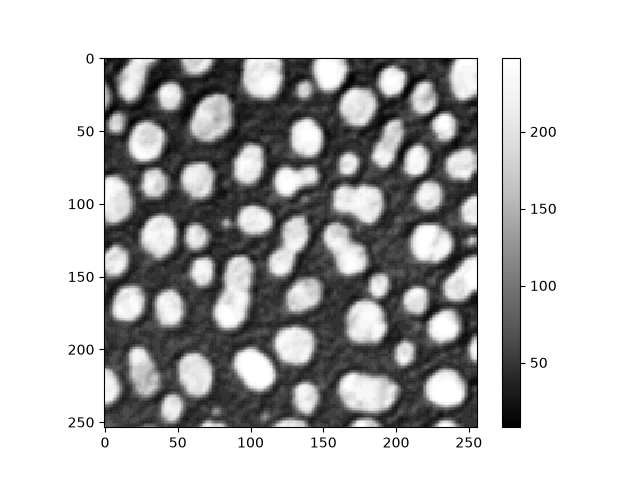
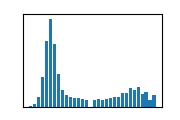

In [2]:
image = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze())
image

## Function doc

In [3]:
print(cle.morphological_chan_vese.__doc__)

Computes an active contour model using the Chan–Vese morphological algorithm.
The output image (dst) should also be the initialization of the contour. If not
provided (nullptr), the function uses a checkerboard pattern initialization.

Parameters
----------
input_image: Image
    Input image to process.
output_image: Optional[Image] (= None)
    Output contour; can also be used to provide initialization.
num_iter: int (= 100)
    Number of iterations.
smoothing: int (= 1)
    Number of smoothing iterations.
lambda1: float (= 1)
    Lambda1.
lambda2: float (= 1)
    Lambda2.
device: Optional[Device] (= None)
    Device to perform the operation on.

Returns
-------
Image



## Run the segmentation

`num_iter` controls how many evolution steps the contour takes, and `smoothing` controls how
many smoothing iterations are applied per step. If no initial contour (`output_image`) is
given, a checkerboard pattern is used as starting point.

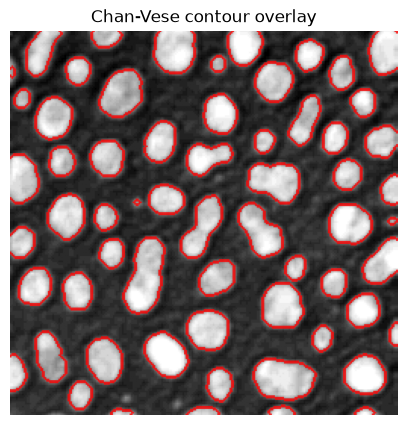

In [20]:
from skimage.segmentation import find_boundaries

segmentation = cle.morphological_chan_vese(
    image,
    num_iter=100,
    smoothing=1,
    lambda1=1,
    lambda2=1,
)
boundaries = find_boundaries(segmentation.get().astype(np.uint8))

plt.figure(figsize=(5, 5))
plt.imshow(image.get(), cmap="gray")
plt.imshow(np.ma.masked_where(~boundaries, boundaries), cmap="autumn", alpha=0.8)
plt.title("Chan-Vese contour overlay")
plt.axis("off")
plt.show()

## Effect of `lambda1` / `lambda2`

`lambda1` weights the contour's tendency to fit the inside region, `lambda2` the outside
region. Increasing `lambda2` relative to `lambda1` tends to shrink the segmented region.

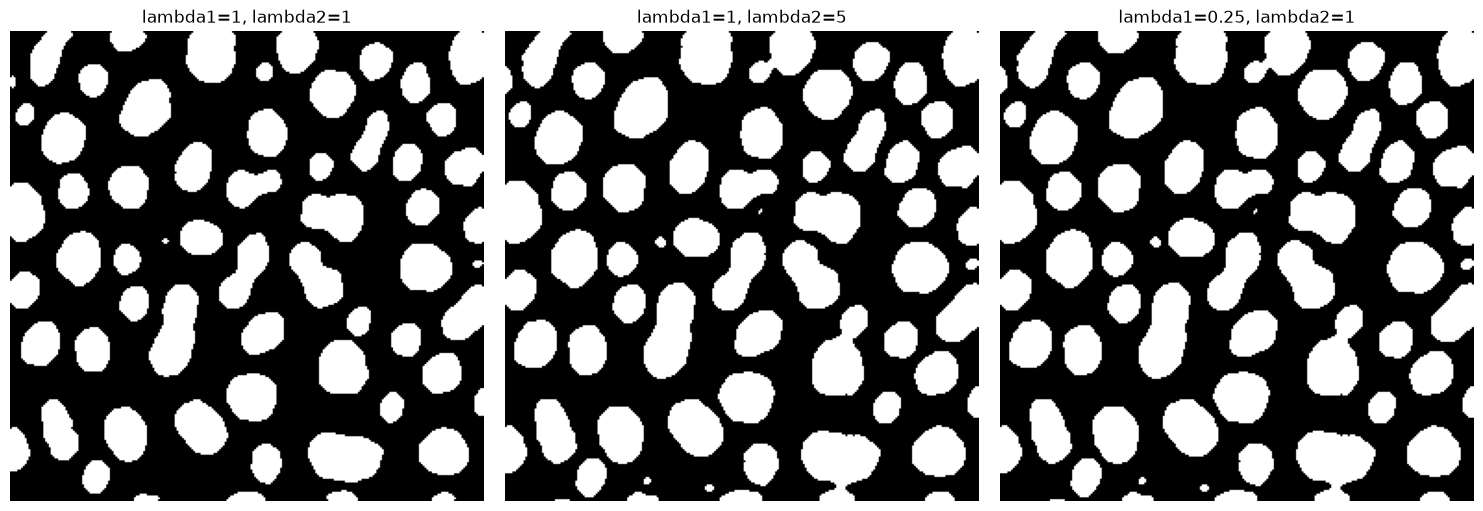

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, (l1, l2) in zip(axs, [(1, 1), (1, 5), (0.25, 1)]):
    result = cle.morphological_chan_vese(image, num_iter=500, smoothing=1, lambda1=l1, lambda2=l2)
    ax.imshow(result.get(), cmap="gray")
    ax.set_title(f"lambda1={l1}, lambda2={l2}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Real data run

array([[2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       ...,
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2]], shape=(590, 590), dtype=uint8, mtype=buffer)
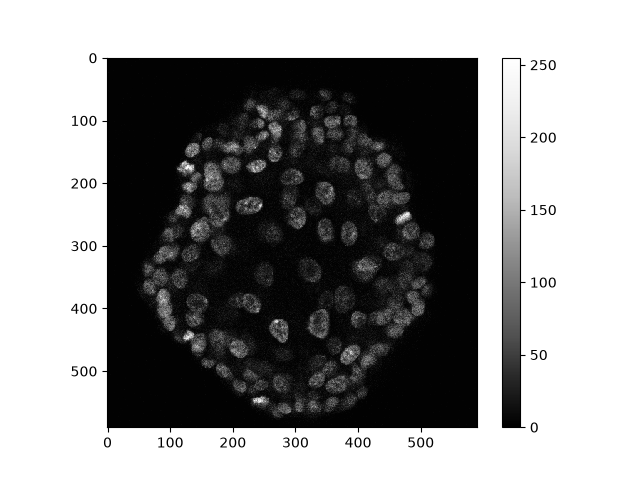
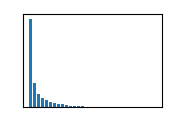

In [25]:
image = cle.push(imread("https://github.com/StRigaud/pyopencl_clahe/raw/refs/heads/main/Test_image/TOrg2%20DAPI-1.tif")[15])    
image

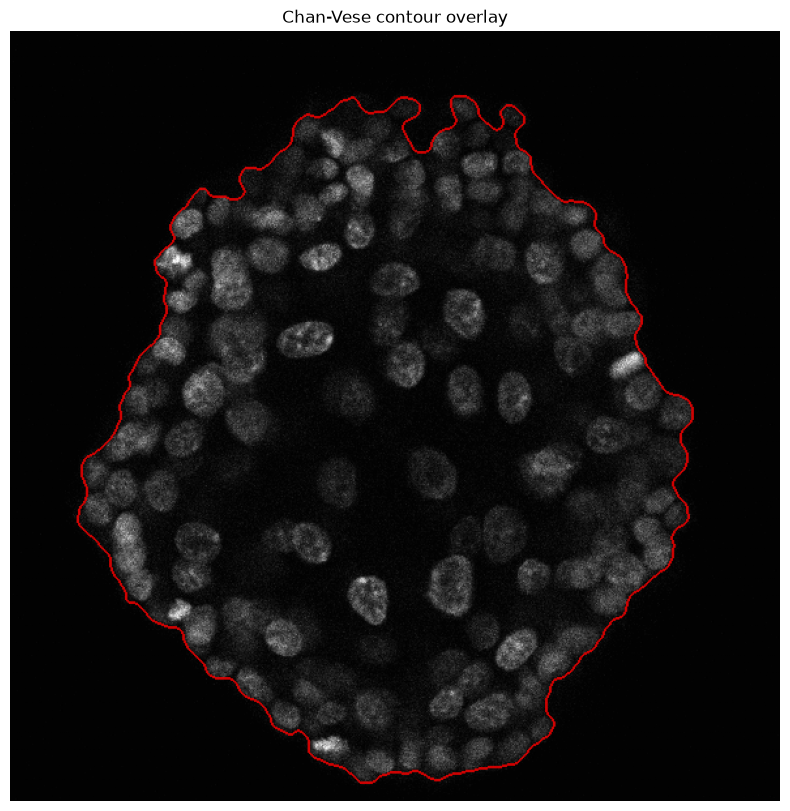

In [30]:
segmentation = cle.morphological_chan_vese(
    image,
    num_iter=400,
    smoothing=3,
    lambda1=0.5,
    lambda2=1,
)
boundaries = find_boundaries(segmentation.get().astype(np.uint8))

plt.figure(figsize=(10, 10))
plt.imshow(image.get(), cmap="gray")
plt.imshow(np.ma.masked_where(~boundaries, boundaries), cmap="autumn", alpha=0.8)
plt.title("Chan-Vese contour overlay")
plt.axis("off")
plt.show()

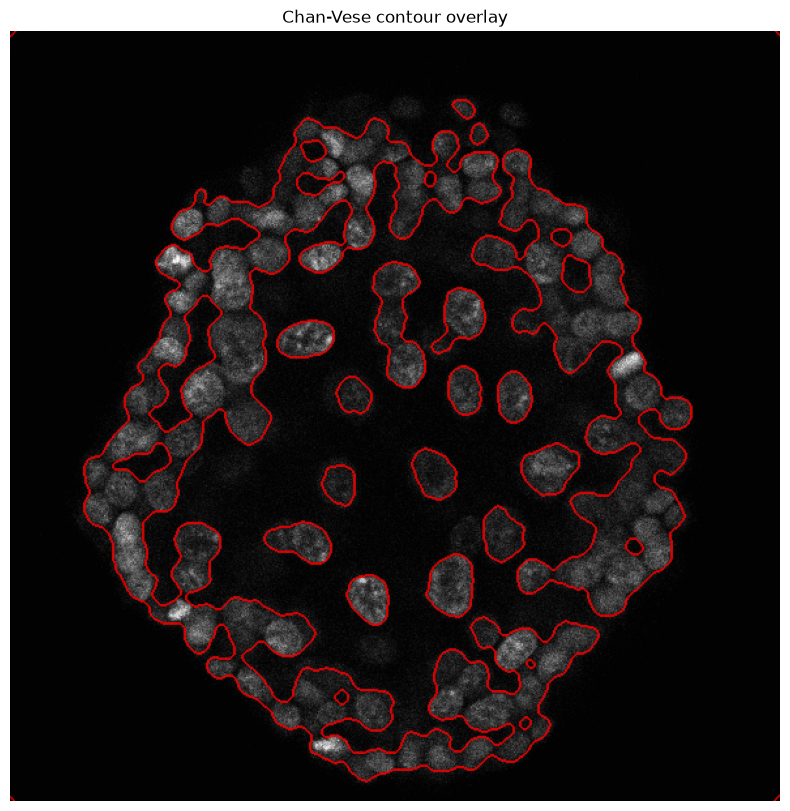

In [41]:
segmentation = cle.morphological_chan_vese(
    image,
    num_iter=500,
    smoothing=3,
    lambda1=1,
    lambda2=1,
)
boundaries = find_boundaries(segmentation.get().astype(np.uint8))

plt.figure(figsize=(10, 10))
plt.imshow(image.get(), cmap="gray")
plt.imshow(np.ma.masked_where(~boundaries, boundaries), cmap="autumn", alpha=0.8)
plt.title("Chan-Vese contour overlay")
plt.axis("off")
plt.show()